# DDoS Detection using EDA and Logistic Regression

This notebook follows the same EDA style as the uploaded `02_EDA_(2) (2).ipynb`:
- Pandas and NumPy
- Seaborn and Matplotlib
- Numerical vs categorical feature identification
- Missing-value heatmap
- Histograms
- Count plots
- Correlation heatmap
- Boxplots
- Basic preprocessing
- Logistic Regression

The target column in the DDoS dataset is `Label`.
`BENIGN` is encoded as `0` and `DDoS` as `1`.

In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# 2. Load dataset
from pandas import read_csv

df = read_csv("/content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (66803, 85)


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443.0,192.168.10.5,54865.0,6.0,7/7/2017 3:30,3.0,2.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80.0,192.168.10.5,55054.0,6.0,7/7/2017 3:30,109.0,1.0,1.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80.0,192.168.10.5,55055.0,6.0,7/7/2017 3:30,52.0,1.0,1.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443.0,192.168.10.16,46236.0,6.0,7/7/2017 3:30,34.0,1.0,1.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443.0,192.168.10.5,54863.0,6.0,7/7/2017 3:30,3.0,2.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [3]:
# 3. Clean column names
df.columns = df.columns.str.strip()

print("Columns:")
print(df.columns.tolist())

Columns:
['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Coun

In [4]:
# 4. Numerical vs Categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG

### Observation

The dataset contains many numerical network-flow features and a small number of categorical/text columns such as IP addresses, Flow ID, Timestamp, and Label.

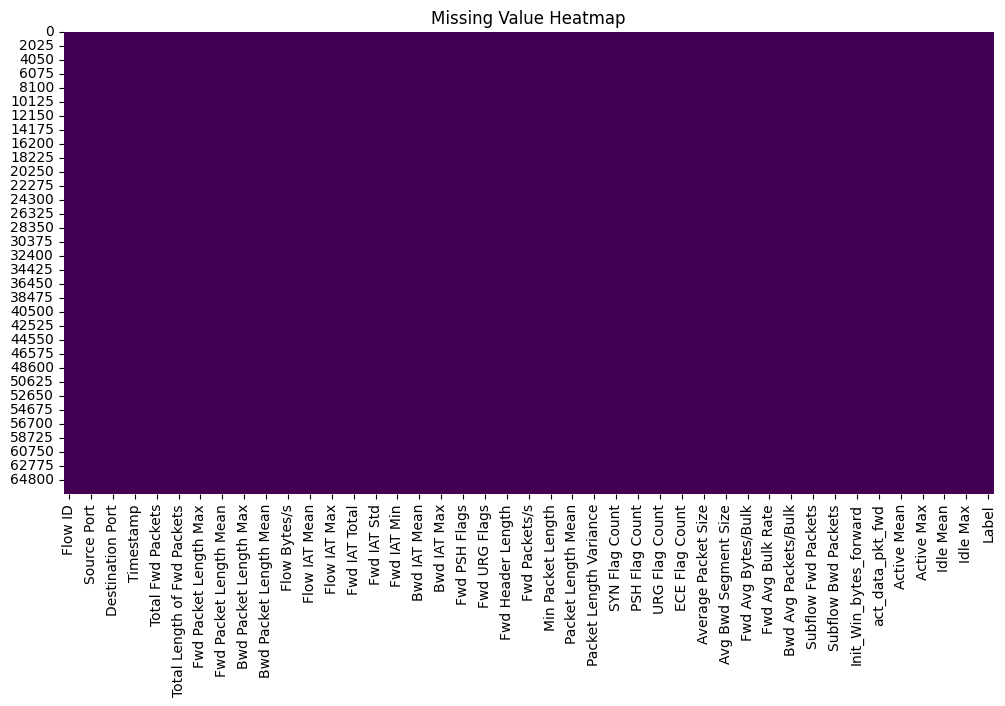

Missing values:
Flow Bytes/s                   4
Destination IP                 1
Source Port                    1
Destination Port               1
Source IP                      1
Fwd Packet Length Max          1
Protocol                       1
Flow Duration                  1
Timestamp                      1
Total Backward Packets         1
Total Length of Fwd Packets    1
Total Length of Bwd Packets    1
Total Fwd Packets              1
Bwd Packet Length Max          1
Fwd Packet Length Min          1
Fwd Packet Length Std          1
Fwd Packet Length Mean         1
Bwd Packet Length Mean         1
Bwd Packet Length Min          1
Bwd Packet Length Std          1
dtype: int64


In [5]:
# 5. Missing Value Heatmap
fig1 = plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")
plt.show()

print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

### Observation

The missing-value heatmap helps identify whether network-flow features contain missing observations before model development.

In [6]:
# 6. Remove duplicate rows
print("Duplicate rows before removal:", df.duplicated().sum())

df = df.drop_duplicates()

print("Dataset Shape after removing duplicates:", df.shape)

Duplicate rows before removal: 2
Dataset Shape after removing duplicates: (66801, 85)


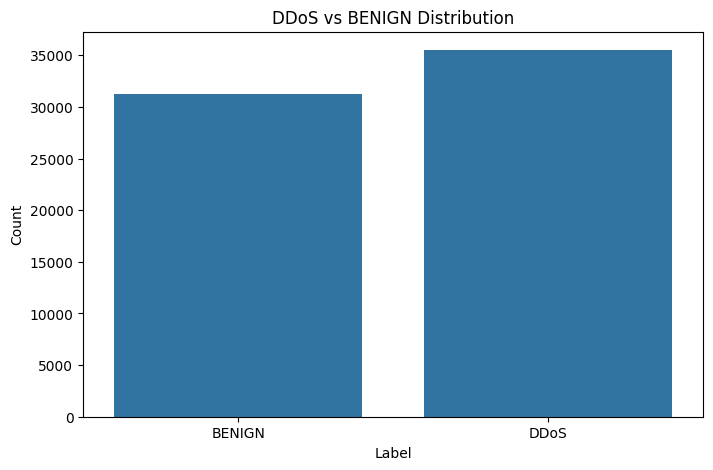

Label
DDoS      35512
BENIGN    31288
Name: count, dtype: int64


In [7]:
# 7. DDoS vs BENIGN distribution
label_counts = df["Label"].value_counts()

fig2 = plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Label"
)

plt.title("DDoS vs BENIGN Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

print(label_counts)

### Observation

The count plot shows the distribution of the two target classes, `BENIGN` and `DDoS`. This is important before training a binary classification model.

<Figure size 1500x800 with 0 Axes>

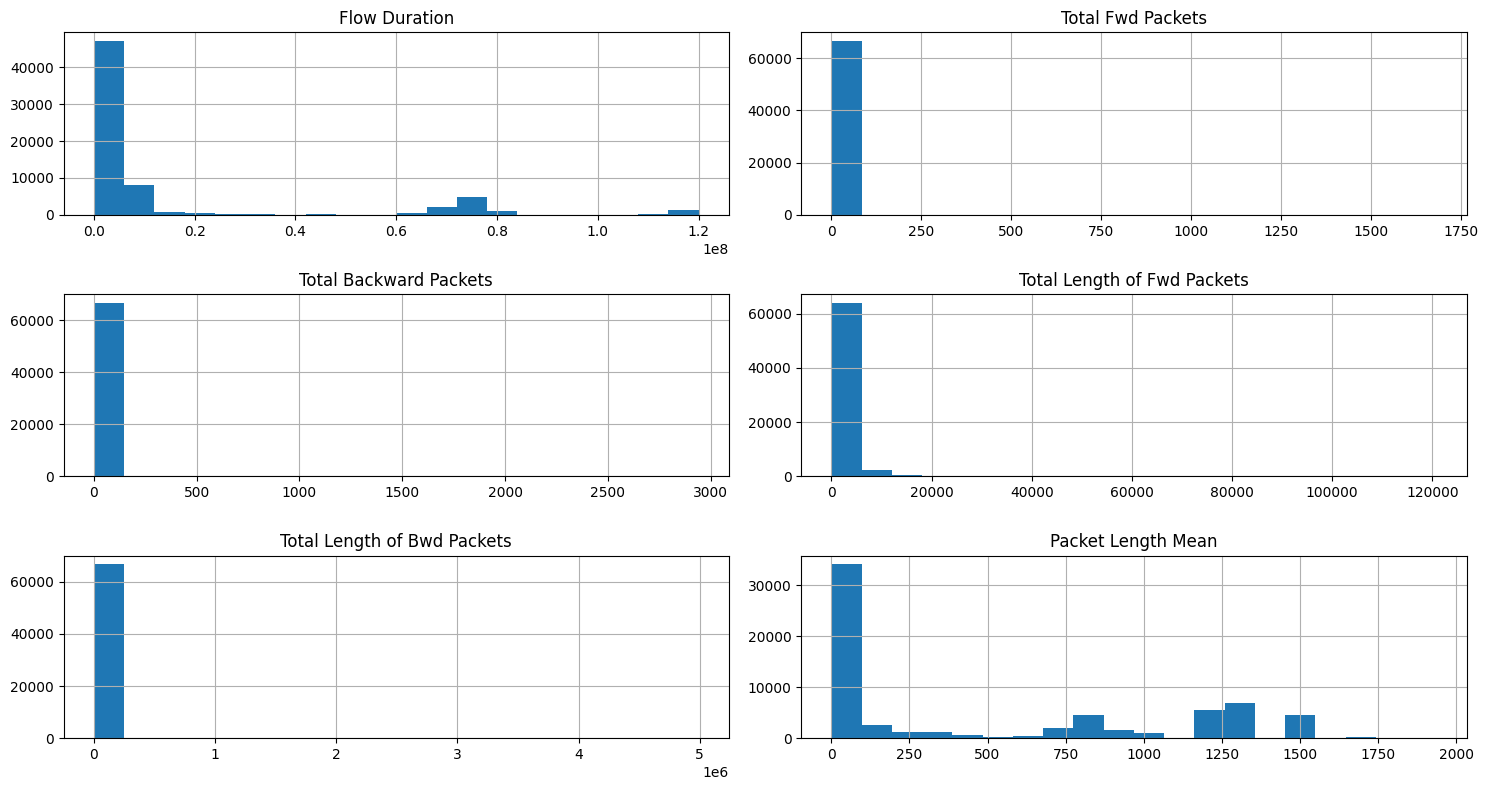

In [8]:
# 8. Histograms of selected numerical features
features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Packet Length Mean"
]

features = [col for col in features if col in df.columns]

fig3 = plt.figure(figsize=(15, 8))

df[features].hist(
    bins=20,
    figsize=(15, 8)
)

plt.tight_layout()
plt.show()

### Observation

The histograms show the distribution of selected network-flow measurements. These distributions help understand the range and variation of traffic-related features.

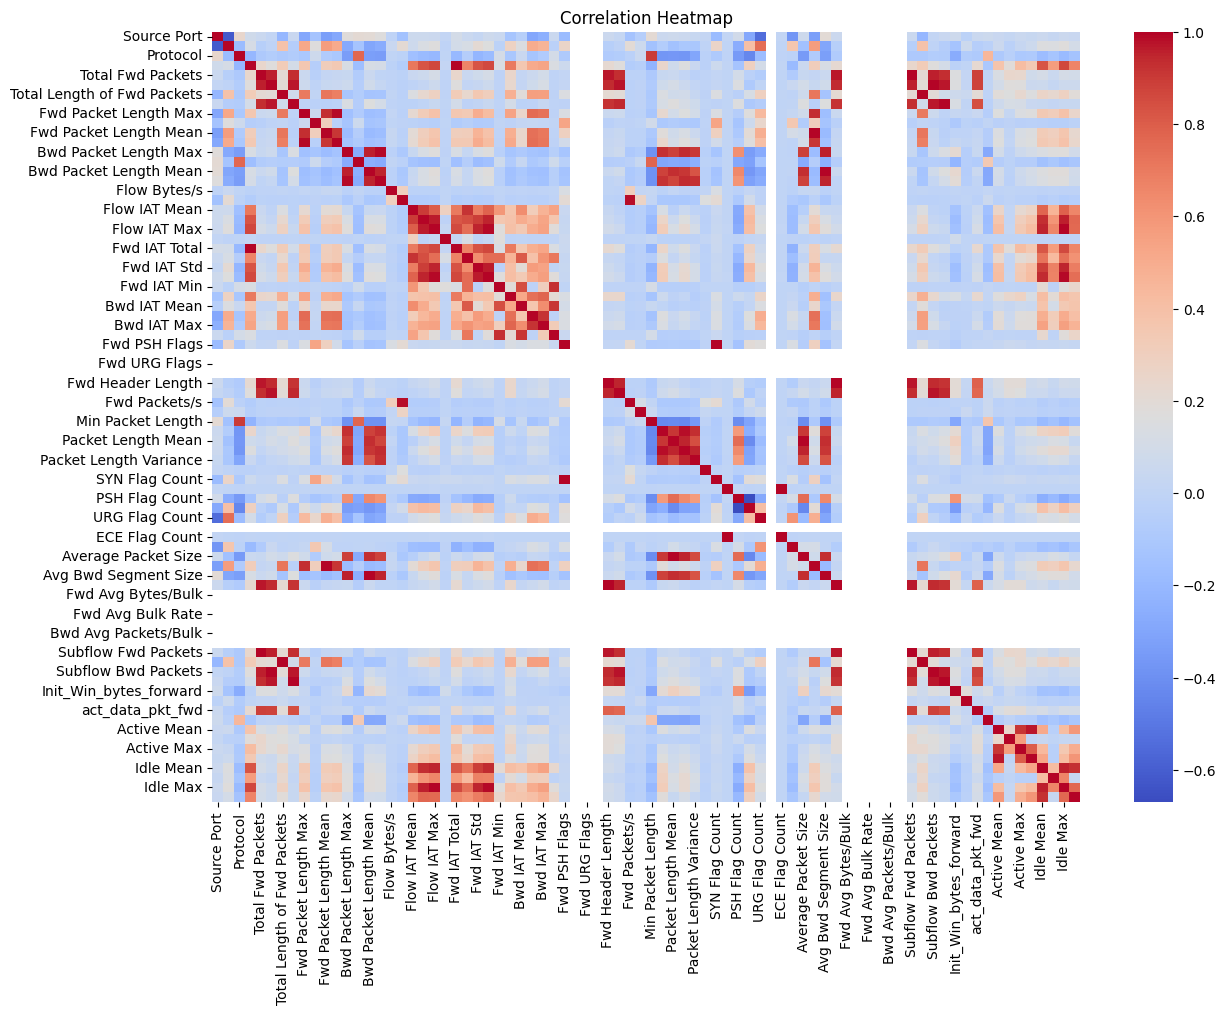

In [9]:
# 9. Correlation Heatmap
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

corr = df[numerical_cols].corr()

fig4 = plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# Correlation Heatmap

A correlation heatmap is used to identify relationships among numerical features before model development.

The correlation coefficient ranges from **-1 to +1**:

- **+1** → strong positive relationship
- **0** → no linear relationship
- **-1** → strong negative relationship

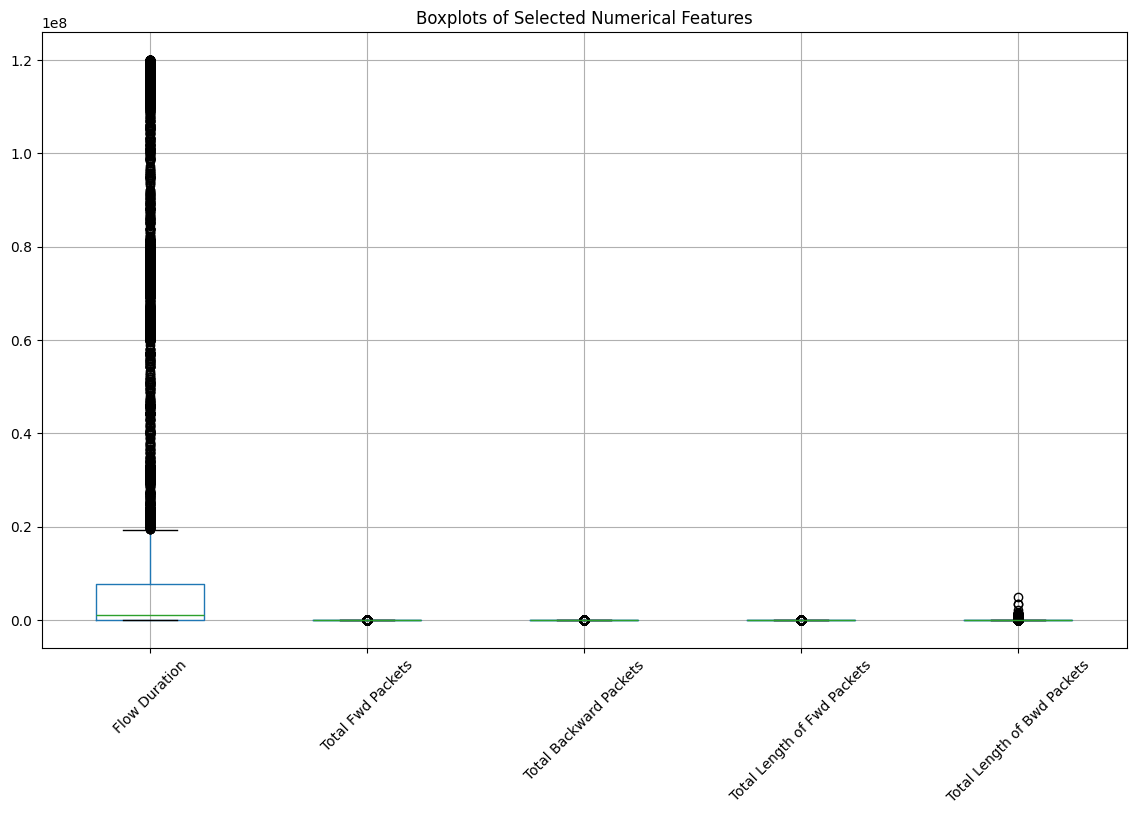

In [10]:
# 10. Boxplots of selected numerical features
numerical_columns = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets"
]

numerical_columns = [col for col in numerical_columns if col in df.columns]

fig5 = plt.figure(figsize=(14, 8))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)
plt.title("Boxplots of Selected Numerical Features")
plt.show()

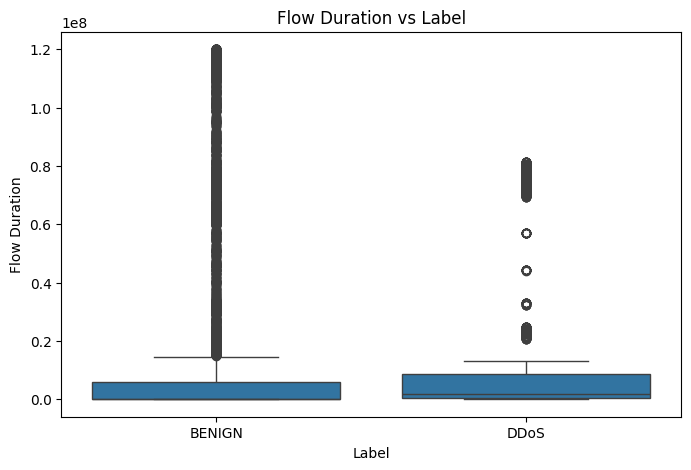

In [11]:
# 11. Boxplot: Flow Duration vs Label
fig6 = plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Label",
    y="Flow Duration",
    data=df
)

plt.title("Flow Duration vs Label")
plt.show()

### Observation

The boxplot compares the selected network-flow feature across the two target classes and helps identify differences in their distributions.

In [12]:
# 12. Prepare target variable
df["Label"] = df["Label"].map({
    "BENIGN": 0,
    "DDoS": 1
})

print(df["Label"].value_counts())

Label
1.0    35512
0.0    31288
Name: count, dtype: int64


In [13]:
# 13. Select numerical features for Logistic Regression

# Text/categorical network identifiers are not used directly.
# Keep only numerical predictor columns and remove the target.
X = df.select_dtypes(include=np.number).drop(columns=["Label"])
y = df["Label"]

# Replace infinite values with NaN and remove rows containing NaN values.
X = X.replace([np.inf, -np.inf], np.nan)

valid_rows = X.notnull().all(axis=1)
X = X[valid_rows]
y = y.loc[X.index]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (66785, 80)
Target Shape: (66785,)


### Preprocessing

For Logistic Regression, the numerical network-flow features are used as predictors. Text-based identifiers such as IP addresses, Flow ID, and Timestamp are not directly used as numerical predictors.

Infinite and missing numerical values are removed before model training.

In [14]:
# 14. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (53428, 80)
Testing data: (13357, 80)


In [15]:
# 15. Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


# Logistic Regression

Logistic Regression is used here as the binary classification model to predict whether a network flow is `BENIGN` or `DDoS`.

In [16]:
# 16. Logistic Regression Model
model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [17]:
# 17. Predictions
y_pred = model.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [18]:
# 18. Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.9969304484539941


Confusion Matrix:
[[6222   33]
 [   8 7094]]


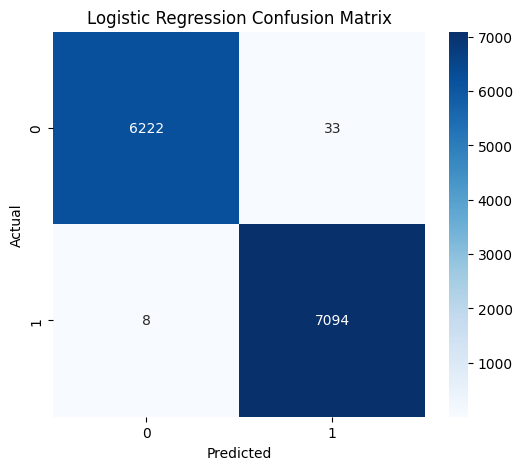

In [19]:
# 19. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
# 20. Classification Report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["BENIGN", "DDoS"]
    )
)

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.99      1.00      6255
        DDoS       1.00      1.00      1.00      7102

    accuracy                           1.00     13357
   macro avg       1.00      1.00      1.00     13357
weighted avg       1.00      1.00      1.00     13357



# Final Observation

The notebook completes the EDA and Logistic Regression workflow for the DDoS dataset.

The workflow includes:
1. Dataset loading
2. Numerical and categorical feature identification
3. Missing-value analysis
4. Duplicate removal
5. Class distribution
6. Histograms
7. Correlation heatmap
8. Boxplots
9. Target encoding
10. Numerical feature selection
11. Train-test split
12. Standard scaling
13. Logistic Regression
14. Accuracy
15. Confusion matrix
16. Classification report